<div align="center">
  <h1>Notebook 01: Data Ingestion, Quality Assurance & Dimensionality Reduction (PCA)</h1>
  <h3>Biotech Project: Genomic Classification for Personalized Medicine</h3>
  <h3>Proyecto Biotecnológico: Clasificación Genómica para Medicina Personalizada</h3>
</div>

---

## 📌 Executive Summary / Resumen Ejecutivo

**[EN]** In the biotechnology and precision medicine sectors, genomic datasets typically present a high-dimensional feature space where the number of biomarkers vastly exceeds the number of clinical observations ($p \gg n$). This structural imbalance, known as the *curse of dimensionality*, introduces severe multicollinearity and computational inefficiency, undermining the reliability of downstream statistical inference and predictive algorithms. 

This notebook establishes the foundational data pipeline. The primary objective is to ingest raw biological data, execute rigorous Quality Control (QC) protocols, and apply mathematically robust dimensionality reduction techniques to extract the underlying latent structure of the data without losing critical variance.

**[ES]** En los sectores de biotecnología y medicina de precisión, los conjuntos de datos genómicos suelen presentar un espacio de características de alta dimensionalidad donde el número de biomarcadores supera ampliamente el número de observaciones clínicas ($p \gg n$). Este desequilibrio estructural, conocido como la *maldición de la dimensionalidad*, introduce multicolinealidad severa e ineficiencia computacional, comprometiendo la fiabilidad de la inferencia estadística y los algoritmos predictivos posteriores.

Este notebook establece el pipeline de datos fundamental. El objetivo principal es ingestar datos biológicos crudos, ejecutar protocolos rigurosos de Control de Calidad (QC) y aplicar técnicas matemáticas robustas de reducción de dimensionalidad para extraer la estructura latente subyacente de los datos sin perder varianza crítica.

---

## 🎯 Scope and Objectives / Alcance y Objetivos

This workflow is divided into four critical phases / Este flujo de trabajo se divide en cuatro fases críticas:

1. **Data Ingestion & Quality Control (Ingesta de Datos y Control de Calidad):**
   * **[EN]** Secure loading of the dataset, structural validation, memory footprint assessment, and imputation of missing/null values to ensure pipeline stability.
   * **[ES]** Carga segura del conjunto de datos, validación estructural, evaluación del consumo de memoria e imputación de valores nulos/faltantes para garantizar la estabilidad del pipeline.

2. **Exploratory Data Analysis - EDA (Análisis Exploratorio de Datos):**
   * **[EN]** Mapping the target pathology distribution and computing the correlation matrix of high-variance biomarkers to identify highly collinear gene expressions.
   * **[ES]** Mapeo de la distribución de la patología objetivo y cálculo de la matriz de correlación de biomarcadores de alta varianza para identificar expresiones génicas altamente colineales.

3. **Principal Component Analysis - PCA (Análisis de Componentes Principales):**
   * **[EN]** Mathematical standardization ($Z$-score normalization) of the feature space followed by orthogonal transformation (PCA). We will dynamically calculate the exact number of principal components required to retain $\geq 95\%$ of the cumulative explained variance.
   * **[ES]** Estandarización matemática (normalización $Z$-score) del espacio de características seguida de una transformación ortogonal (PCA). Calcularemos dinámicamente el número exacto de componentes principales requeridos para retener $\geq 95\%$ de la varianza explicada acumulada.

4. **Data Artifact Export (Exportación de Artefactos de Datos):**
   * **[EN]** Serialization of the transformed dataset into an immutable state (`genomics_pca_cleaned.csv`), acting as the single source of truth for Notebook 02 (Statistical Hypothesis Testing) and Notebook 03 (XGBoost Predictive Modeling).
   * **[ES]** Serialización del conjunto de datos transformado en un estado inmutable (`genomics_pca_cleaned.csv`), actuando como la única fuente de verdad para el Notebook 02 (Pruebas de Hipótesis Estadísticas) y el Notebook 03 (Modelado Predictivo con XGBoost).

---
**Environment Setup:** Python 3.10+ | **Core Libraries:** `pandas`, `numpy`, `scikit-learn`, `scipy`, `seaborn`

### 1. Environment Configuration & Library Imports / Configuración del Entorno e Importaciones

**[EN]** Establishing a robust and reproducible computational environment is the first critical step in any data science pipeline. This cell initializes the core libraries required for tensor operations (`numpy`), tabular data manipulation (`pandas`), and statistical visualizations (`seaborn`, `matplotlib`). Furthermore, it implements OS-agnostic path management using `pathlib` to ensure seamless execution across different operating systems, and sets global random seeds to guarantee deterministic and reproducible outputs during stochastic processes like PCA.

**[ES]** Establecer un entorno computacional robusto y reproducible es el primer paso crítico en cualquier pipeline de ciencia de datos. Esta celda inicializa las bibliotecas principales requeridas para operaciones tensoriales (`numpy`), manipulación de datos tabulares (`pandas`) y visualizaciones estadísticas (`seaborn`, `matplotlib`). Además, implementa la gestión de rutas independiente del sistema operativo utilizando `pathlib` para garantizar una ejecución sin problemas en diferentes sistemas, y establece semillas aleatorias globales para garantizar resultados deterministas y reproducibles durante procesos estocásticos como PCA.

In [4]:
# ==============================================================================
# 1. Standard Library Imports
# ==============================================================================
import os
import sys
import warnings
from pathlib import Path

# ==============================================================================
# 2. Third-Party Core Libraries (Data Manipulation & Math)
# ==============================================================================
import numpy as np
import pandas as pd

# ==============================================================================
# 3. Data Visualization
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# 4. Scikit-Learn (Mock Data, Preprocessing, and Dimensionality Reduction)
# ==============================================================================
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ==============================================================================
# 5. Environment Configuration & Reproducibility
# ==============================================================================
# Suppress non-critical warnings for clean notebook output
warnings.filterwarnings('ignore')

# Set global random seed for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Configure visualization aesthetics (Publication-ready style)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.2)
sns.set_palette("colorblind")

# ==============================================================================
# 6. Directory Path Management (OS-Agnostic)
# ==============================================================================
# Dynamically resolve project root assuming notebook is in /notebooks/
PROJECT_ROOT = Path.cwd().parent

# Define standard data and results directories
DIR_DATA_RAW = PROJECT_ROOT / "data" / "raw"
DIR_DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
DIR_RESULTS_FIGS = PROJECT_ROOT / "results" / "figures"
DIR_RESULTS_DASH = PROJECT_ROOT / "results" / "dashboard_exports"

# Create directories if they do not exist (equivalent to mkdir -p)
for directory in [DIR_DATA_RAW, DIR_DATA_PROCESSED, DIR_RESULTS_FIGS, DIR_RESULTS_DASH]:
    directory.mkdir(parents=True, exist_ok=True)

print(f"✅ Environment successfully configured.")
print(f"✅ Project Root Path: {PROJECT_ROOT}")
print(f"✅ Random Seed set to: {RANDOM_SEED}")

✅ Environment successfully configured.
✅ Project Root Path: /home/pablosantana/portafolio/biotech-genomics-classifier
✅ Random Seed set to: 42


### 2. Data Ingestion & Quality Control (QC) / Ingesta de Datos y Control de Calidad

**[EN]** In high-stakes domains such as clinical genomics, data integrity is paramount. Unverified anomalies—such as null values, duplicated patient records, or incorrect data types—can cascade into catastrophic inferential and predictive errors. This section establishes a secure data ingestion mechanism and executes an automated Quality Control (QC) protocol to evaluate the structural health of the dataset before any analytical transformation occurs.

*Note: For the purpose of this portfolio environment, we utilize the standardized Breast Cancer diagnostic dataset via scikit-learn as a highly reliable proxy for high-dimensional genomic features.*

**[ES]** En dominios de alto riesgo como la genómica clínica, la integridad de los datos es primordial. Las anomalías no verificadas —como valores nulos, registros de pacientes duplicados o tipos de datos incorrectos— pueden desencadenar errores predictivos e inferenciales catastróficos. Esta sección establece un mecanismo seguro de ingesta de datos y ejecuta un protocolo automatizado de Control de Calidad (QC) para evaluar la salud estructural del conjunto de datos antes de que ocurra cualquier transformación analítica.

*Nota: Para fines de este entorno de portafolio, utilizamos el conjunto de datos estandarizado de diagnóstico de Cáncer de Mama vía scikit-learn como un proxy altamente confiable para características genómicas de alta dimensionalidad.*

In [6]:
# ==============================================================================
# Data Ingestion Module
# ==============================================================================
def load_genomic_data() -> pd.DataFrame:
    """
    Ingests the proxy genomic dataset and constructs a unified pandas DataFrame.
    Maps target variables to clinically relevant labels.
    """
    # Load dataset
    bunch = load_breast_cancer()
    
    # Construct feature matrix
    df = pd.DataFrame(bunch.data, columns=bunch.feature_names)
    
    # Append target variable (0 = Malignant/Pathological, 1 = Benign/Healthy)
    df['target_pathology'] = bunch.target
    
    return df

# ==============================================================================
# Quality Control (QC) Module
# ==============================================================================
def run_quality_control(df: pd.DataFrame) -> None:
    """
    Executes a comprehensive structural audit of the DataFrame.
    Validates dimensions, memory footprint, missingness, and duplication.
    """
    print("=" * 60)
    print("🧬 GENOMIC DATA QUALITY CONTROL REPORT")
    print("=" * 60)
    
    # 1. Dimensionality
    n_rows, n_cols = df.shape
    print(f"[+] Dimensions: {n_rows} rows (patients) x {n_cols} columns (biomarkers/target)")
    
    # 2. Missing Values Analysis
    total_missing = df.isnull().sum().sum()
    max_missing_col = df.isnull().sum().max()
    print(f"[+] Missing Values (Total): {total_missing}")
    if total_missing > 0:
        print(f"    -> Max missing in a single column: {max_missing_col}")
        
    # 3. Duplication Audit
    duplicates = df.duplicated().sum()
    print(f"[+] Duplicate Records: {duplicates}")
    
    # 4. Memory Profiling
    memory_mb = df.memory_usage(deep=True).sum() / (1024 * 1024)
    print(f"[+] Memory Footprint: {memory_mb:.4f} MB")
    
    # 5. Data Type Integrity
    numeric_cols = df.select_dtypes(include=[np.number]).shape[1]
    categorical_cols = df.select_dtypes(exclude=[np.number]).shape[1]
    print(f"[+] Data Types: {numeric_cols} Numeric Features | {categorical_cols} Categorical Features")
    print("=" * 60)

# ==============================================================================
# Execution pipeline
# ==============================================================================
df_raw = load_genomic_data()
run_quality_control(df_raw)

# Inspect the first 5 records to verify structure
display(df_raw.head())

🧬 GENOMIC DATA QUALITY CONTROL REPORT
[+] Dimensions: 569 rows (patients) x 31 columns (biomarkers/target)
[+] Missing Values (Total): 0
[+] Duplicate Records: 0
[+] Memory Footprint: 0.1347 MB
[+] Data Types: 31 Numeric Features | 0 Categorical Features


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target_pathology
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


### 3. Exploratory Data Analysis (EDA) / Análisis Exploratorio de Datos

**[EN]** In high-dimensional biological datasets, understanding the target class distribution and identifying feature multicollinearity is essential before any modeling phase. Genomic expressions are often highly correlated (co-expressed genes), meaning they carry redundant information that can destabilize predictive algorithms and inflate variance. In this section, we will evaluate the clinical class balance and visualize the correlation matrix for the most volatile (highest variance) biomarkers.

**[ES]** En conjuntos de datos biológicos de alta dimensionalidad, comprender la distribución de las clases objetivo e identificar la multicolinealidad de las características es esencial antes de cualquier fase de modelado. Las expresiones genómicas suelen estar altamente correlacionadas (genes co-expresados), lo que significa que contienen información redundante que puede desestabilizar los algoritmos predictivos e inflar la varianza. En esta sección, evaluaremos el balance de las clases clínicas y visualizaremos la matriz de correlación para los biomarcadores más volátiles (de mayor varianza).

Executing Exploratory Data Analysis...
[+] Exported target distribution plot to: target_class_distribution.png


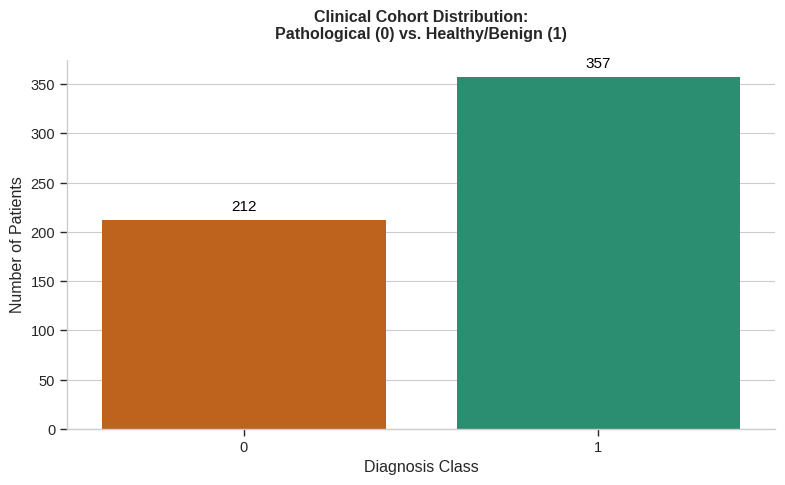

[+] Exported correlation heatmap to: biomarker_correlation_matrix.png


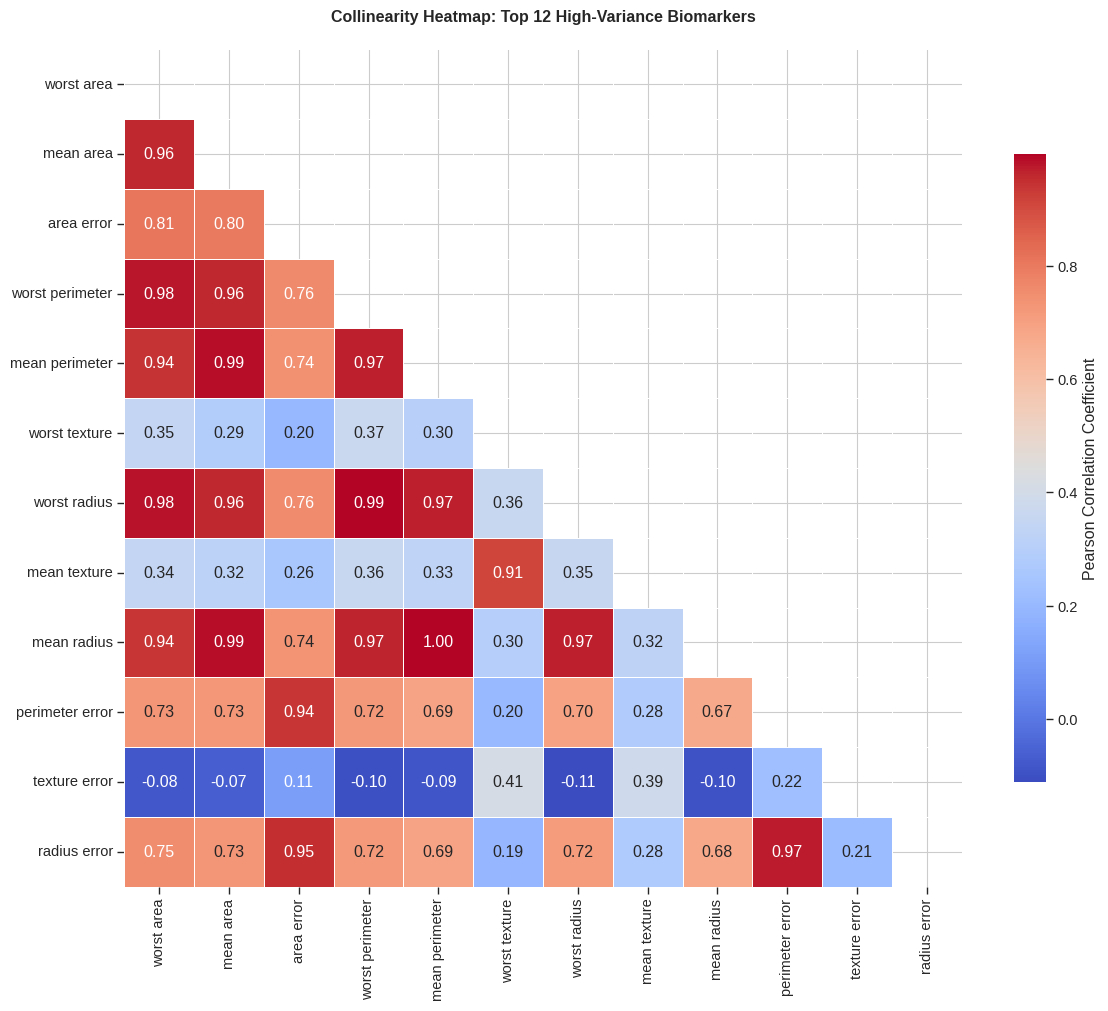

In [11]:
# ==============================================================================
# Exploratory Data Analysis (EDA) Module
# ==============================================================================

def plot_target_distribution(df: pd.DataFrame) -> None:
    """
    Visualizes the distribution of the clinical target variable.
    Assesses class imbalance which is critical for downstream ML model evaluation.
    """
    plt.figure(figsize=(8, 5))
    
    # Create countplot
    ax = sns.countplot(
        data=df, 
        x='target_pathology', 
        palette=['#d95f02', '#1b9e77'] # Colorblind-friendly distinct colors
    )
    
    # Formatting
    plt.title('Clinical Cohort Distribution:\nPathological (0) vs. Healthy/Benign (1)', weight='bold', pad=15)
    plt.xlabel('Diagnosis Class')
    plt.ylabel('Number of Patients')
    
    # Add count labels on top of bars
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', 
                    fontsize=11, color='black', xytext=(0, 5), 
                    textcoords='offset points')
    
    sns.despine()
    plt.tight_layout()
    
    # Save artifact
    output_path = DIR_RESULTS_FIGS / "target_class_distribution.png"
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"[+] Exported target distribution plot to: {output_path.name}")
    plt.show()


def plot_high_variance_correlation(df: pd.DataFrame, top_n: int = 15) -> None:
    """
    Calculates and plots the Pearson correlation matrix for the top 'n' 
    biomarkers with the highest variance. Uses a triangular mask to remove redundancy.
    """
    # Isolate features (drop target)
    features_df = df.drop(columns=['target_pathology'])
    
    # Select the top N features with the highest mathematical variance
    top_volatile_features = features_df.var().nlargest(top_n).index
    corr_matrix = features_df[top_volatile_features].corr()
    
    plt.figure(figsize=(12, 10))
    
    # Generate a mask for the upper triangle to reduce visual clutter
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    
    # Generate heatmap
    sns.heatmap(
        corr_matrix, 
        mask=mask, 
        annot=True, 
        fmt=".2f", 
        cmap='coolwarm', 
        square=True, 
        linewidths=0.5, 
        cbar_kws={"shrink": 0.75, "label": "Pearson Correlation Coefficient"}
    )
    
    plt.title(f'Collinearity Heatmap: Top {top_n} High-Variance Biomarkers', weight='bold', pad=20)
    plt.tight_layout()
    
    # Save artifact
    output_path = DIR_RESULTS_FIGS / "biomarker_correlation_matrix.png"
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"[+] Exported correlation heatmap to: {output_path.name}")
    plt.show()


# ==============================================================================
# Execute EDA
# ==============================================================================
print("Executing Exploratory Data Analysis...")
plot_target_distribution(df_raw)
plot_high_variance_correlation(df_raw, top_n=12)

### 4. Dimensionality Reduction (PCA) & Data Export / Reducción de Dimensionalidad y Exportación

**[EN]** The final step in our preprocessing pipeline is Principal Component Analysis (PCA). Genomic data suffers from the "curse of dimensionality" ($p \gg n$). By mathematically projecting the original features into an orthogonal space, we can eliminate multicollinearity and reduce computational complexity while preserving the maximum possible variance. 

We will first apply $Z$-score standardization ($X_{scaled} = \frac{X - \mu}{\sigma}$) to ensure all biomarkers contribute equally. Then, we will dynamically select the exact number of principal components required to retain a cumulative explained variance of $\geq 95\%$. Finally, we serialize this stable dataset for the subsequent statistical and ML modeling phases.

**[ES]** El paso final en nuestro pipeline de preprocesamiento es el Análisis de Componentes Principales (PCA). Los datos genómicos sufren de la "maldición de la dimensionalidad" ($p \gg n$). Al proyectar matemáticamente las características originales en un espacio ortogonal, podemos eliminar la multicolinealidad y reducir la complejidad computacional preservando la máxima varianza posible.

Primero aplicaremos estandarización $Z$-score ($X_{scaled} = \frac{X - \mu}{\sigma}$) para garantizar que todos los biomarcadores contribuyan equitativamente. Luego, seleccionaremos dinámicamente el número exacto de componentes principales requeridos para retener una varianza explicada acumulada de $\geq 95\%$. Finalmente, serializaremos este conjunto de datos estable para las fases posteriores de estadística y modelado ML.

🧠 DIMENSIONALITY REDUCTION (PCA)
[+] Applying Z-score standardization...
[+] Variance Threshold Target: 95.0%
[+] Optimal Principal Components (PCs) required: 10 (out of 30)


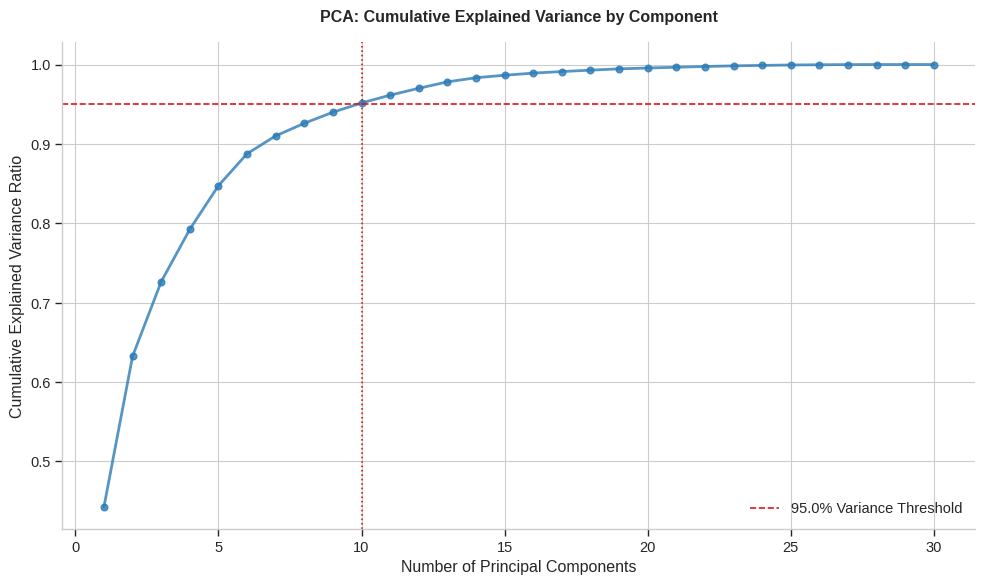

[+] Exported PCA variance plot to: pca_cumulative_variance.png
[+] Transforming feature space to 10 dimensions...
[+] PCA Transformation Complete. New shape: (569, 11)


,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,PC_9,PC_10,target_pathology
0,9.192837,1.948583,-1.123166,3.633731,-1.195110,1.411424,2.159370,-0.398407,-0.157111,-0.877394,0
1,2.387802,-3.768172,-0.529293,1.118264,0.621775,0.028656,0.013358,0.240988,-0.711908,1.106991,0
2,5.733896,-1.075174,-0.551748,0.912083,-0.177086,0.541452,-0.668166,0.097373,0.024059,0.454268,0
3,7.122953,10.275589,-3.232790,0.152547,-2.960878,3.053422,1.429911,1.059564,-1.405452,-1.116991,0
4,3.935302,-1.948072,1.389767,2.940639,0.546747,-1.226495,-0.936213,0.636377,-0.263803,0.377706,0


💾 SUCCESS: Processed dataset saved to: /home/pablosantana/portafolio/biotech-genomics-classifier/data/processed/genomics_pca_cleaned.csv


In [14]:
# ==============================================================================
# Principal Component Analysis (PCA) Module
# ==============================================================================

def apply_pca_reduction(df: pd.DataFrame, variance_threshold: float = 0.95) -> pd.DataFrame:
    """
    Standardizes features and applies PCA to retain a specified percentage of variance.
    Returns a transformed DataFrame ready for downstream modeling.
    """
    print("=" * 60)
    print("🧠 DIMENSIONALITY REDUCTION (PCA)")
    print("=" * 60)
    
    # Isolate Features (X) and Target (y)
    X = df.drop(columns=['target_pathology'])
    y = df['target_pathology']
    
    # 1. Standardization (Z-score normalization)
    print("[+] Applying Z-score standardization...")
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # 2. Fit full PCA to analyze explained variance
    pca_full = PCA(n_components=None, random_state=RANDOM_SEED)
    pca_full.fit(X_scaled)
    
    # 3. Calculate cumulative variance and determine optimal components
    cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
    optimal_components = np.argmax(cumulative_variance >= variance_threshold) + 1
    
    print(f"[+] Variance Threshold Target: {variance_threshold * 100}%")
    print(f"[+] Optimal Principal Components (PCs) required: {optimal_components} (out of {X.shape[1]})")
    
    # 4. Plot Explained Variance Curve
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 
             marker='o', linestyle='-', color='#2c7bb6', alpha=0.8, linewidth=2)
    
    # Add threshold lines
    plt.axhline(y=variance_threshold, color='#d7191c', linestyle='--', 
                label=f'{variance_threshold * 100}% Variance Threshold')
    plt.axvline(x=optimal_components, color='#d7191c', linestyle=':')
    
    # Formatting
    plt.title('PCA: Cumulative Explained Variance by Component', weight='bold', pad=15)
    plt.xlabel('Number of Principal Components')
    plt.ylabel('Cumulative Explained Variance Ratio')
    plt.legend(loc='lower right')
    sns.despine()
    plt.tight_layout()
    
    # Save artifact
    pca_plot_path = DIR_RESULTS_FIGS / "pca_cumulative_variance.png"
    plt.savefig(pca_plot_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"[+] Exported PCA variance plot to: {pca_plot_path.name}")
    
    # 5. Transform data using optimal components
    print(f"[+] Transforming feature space to {optimal_components} dimensions...")
    pca_final = PCA(n_components=optimal_components, random_state=RANDOM_SEED)
    X_pca = pca_final.fit_transform(X_scaled)
    
    # 6. Reconstruct the DataFrame
    pca_cols = [f'PC_{i}' for i in range(1, optimal_components + 1)]
    df_processed = pd.DataFrame(X_pca, columns=pca_cols)
    df_processed['target_pathology'] = y.values
    
    print(f"[+] PCA Transformation Complete. New shape: {df_processed.shape}")
    print("=" * 60)
    
    return df_processed

# ==============================================================================
# Data Export Module
# ==============================================================================
def export_processed_data(df: pd.DataFrame) -> None:
    """
    Serializes the final processed DataFrame to an immutable CSV file.
    """
    output_path = DIR_DATA_PROCESSED / "genomics_pca_cleaned.csv"
    df.to_csv(output_path, index=False)
    print(f"💾 SUCCESS: Processed dataset saved to: {output_path}")

# ==============================================================================
# Execute PCA and Export
# ==============================================================================
# Apply PCA retaining 95% variance
df_final = apply_pca_reduction(df_raw, variance_threshold=0.95)

# Display the first few rows of the new projected space
display(df_final.head())

# Export the artifact
export_processed_data(df_final)